In [1]:
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install tensorflow
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
 


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


c:\Users\Gisele\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


### Ler dados

In [2]:
df = pd.read_csv("all_emails.csv")

id_col, text_col, y_col = "id", "text", "spam"

df = df[[text_col, y_col]].dropna()
df[y_col] = df[y_col].astype(int)

df.head()


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: 4 color printing special request add...,1
3,"Subject: do not have money , get software cds ...",1
4,"Subject: great nnews hello , welcome to medzo...",1


### Análise Exploratória de Dados (EDA)

Observa-se que há uma diferença na quantidade de e-mails classificados como spam e não spam, caracterizando um possível desbalanceamento de classes.

A distribuição de comprimento de e-mails por classe nos mostra que não existe discrepância no número de caracteres

spam
0    3234
1    1026
Name: count, dtype: int64
count     4260.000000
mean      1540.369718
std       1935.621151
min         13.000000
25%        503.000000
50%        976.500000
75%       1891.250000
max      43952.000000
Name: text, dtype: float64


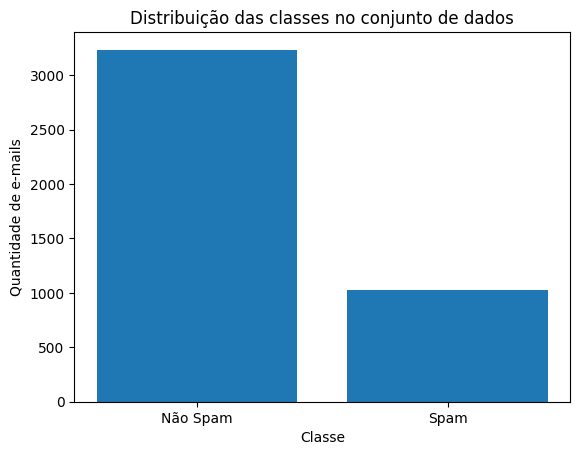

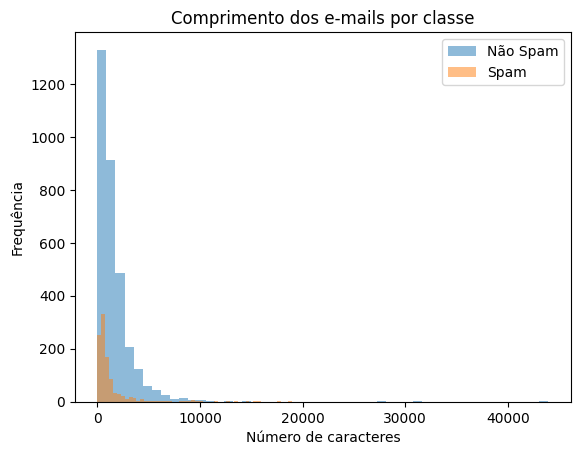

In [3]:
print(df[y_col].value_counts())
print(df[text_col].apply(len).describe())

#Composição das classes (proporção)
class_counts = df[y_col].value_counts()

plt.figure()
plt.bar(class_counts.index, class_counts.values)
plt.xticks([0, 1], ["Não Spam", "Spam"])
plt.xlabel("Classe")
plt.ylabel("Quantidade de e-mails")
plt.title("Distribuição das classes no conjunto de dados")
plt.show()

class_counts


df["text_length_chars"] = df[text_col].str.len()

#comparar spam com não spam
plt.figure()
plt.hist(
    df[df[y_col] == 0]["text_length_chars"],
    bins=50,
    alpha=0.5,
    label="Não Spam"
)

plt.hist(
    df[df[y_col] == 1]["text_length_chars"],
    bins=50,
    alpha=0.5,
    label="Spam"
)

plt.xlabel("Número de caracteres")
plt.ylabel("Frequência")
plt.title("Comprimento dos e-mails por classe")
plt.legend()
plt.show()




### Normalização
* Conversão para minúsculas

* Remoção de HTML

* Remoção de URLs

* Normalização de espaços

* Substituição controlada de números

* Preservação de tokens especiais

In [4]:
# Normalização
def normalize_text(text):
    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " <URL> ", text)

    # Replace numbers with token
    text = re.sub(r"\d+", " <NUM> ", text)

    # Remove excessive punctuation repetition
    text = re.sub(r"([!?.,]){2,}", r"\1", text)

    # Normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["text_norm"] = df[text_col].apply(normalize_text)
df[["text", "text_norm"]].head(3)

df["text"] = df["text_norm"]


if "text_length_chars" not in df.columns:
    df["text_length_chars"] = df[text_col].str.len()


### Tokenização
Número máximo para evitar overfitting

#### Tokenizer

* Cria um vocabulário

* Atribui índices numéricos a palavras

#### Para palavras fora do vocabuláro (ultrapassar tamanho máximo)
* Limita o vocabulário às palavras mais frequentes

* Palavras fora desse conjunto → <OOV>

In [5]:
#tokenização e padding
MAX_WORDS = 15000
MAX_LEN = 500


tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df[text_col])

sequences = tokenizer.texts_to_sequences(df[text_col])
X = pad_sequences(sequences, maxlen=MAX_LEN)

y = df[y_col].values


### Configuração da placa de vídeo (ignorar)

In [6]:
%pip install --index-url https://download.pytorch.org/whl/cpu torch torchvision torchaudio
%pip install torch-directml

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
%%python -m pip install --upgrade pip setuptools wheel
%pip install --index-url https://download.pytorch.org/whl/torch_stable.html torch
%pip install --index-url https://download.pytorch.org/whl/torch_stable.html torch-directml


Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Executable: c:\Users\Gisele\AppData\Local\Programs\Python\Python311\python.exe

== Instalando torch (CPU) e dependências ==
install returncode: 0
--- stdout ---
 Using pip 25.3 from c:\Users\Gisele\AppData\Local\Programs\Python\Python311\Lib\site-packages\pip (python 3.11)
Looking in indexes: https://download.pytorch.org/whl/cpu
INFO: pip is looking at multiple versions of torchaudio to determine which version is compatible with other requirements. This could take a while.
  Obtaining dependency information for torchaudio from https://download.pytorch.org/whl/cpu/torchaudio-2.9.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for torchaudio from https://download.pytorch.org/whl/cpu/torchaudio-2.8.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for torchaudio from https://download.pytorch.org/whl/cpu/torchaudio-2.7.1%2Bcpu-cp311-cp311-win_am

In [7]:
import torch, torch_directml
device = torch_directml.device()
print("Backend DirectML ativo:", device)

Backend DirectML ativo: privateuseone:0


### Modelo Simples

### Divisão de dados

In [8]:
# Divisão treino/teste e preparação dos tensores
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import torch

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train, dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=128)



In [9]:
# Balanceamento de classes
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calcular pesos das classes com base em y_train
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Pesos de classe:", class_weights)

# Função de perda ponderada (Binary Cross Entropy)
def weighted_bce_loss(output, target, weights):
    loss = -(weights[1]*target*torch.log(output + 1e-8) +
             weights[0]*(1 - target)*torch.log(1 - output + 1e-8))
    return loss.mean()


Pesos de classe: tensor([0.6587, 2.0755], device='privateuseone:0')


### CNN simples - Definição do modelo

In [10]:
# Modelo simples: CNN 1D para classificação de SPAM

import torch.nn as nn
import torch_directml

device = torch_directml.device()

class ImprovedTextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, num_filters=64, kernel_size=5):
        super(ImprovedTextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.conv = nn.Conv1d(in_channels=embedding_dim,
                              out_channels=num_filters,
                              kernel_size=kernel_size)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc1 = nn.Linear(num_filters, 32)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)           # [batch, seq, emb]
        x = x.permute(0, 2, 1)          # [batch, emb, seq] p/ Conv1d
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x).squeeze(2)     # [batch, num_filters]
        x = self.dropout(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x.squeeze()

vocab_size = MAX_WORDS
model_cnn = ImprovedTextCNN(vocab_size).to(device)
print(model_cnn)


ImprovedTextCNN(
  (embedding): Embedding(15000, 64, padding_idx=0)
  (conv): Conv1d(64, 64, kernel_size=(5,), stride=(1,))
  (relu): ReLU()
  (pool): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


Pesos aplicados às classes [não spam, spam]: [1.        0.6226553]

Treinando modelo CNN ajustado...



c:\Users\Gisele\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\functional.py:1123: UserWarning: The operator 'aten::adaptive_max_pool2d.out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  return torch.adaptive_max_pool1d(input, output_size)


Época [1/8] - Loss médio: 0.4268
Época [2/8] - Loss médio: 0.3579
Época [3/8] - Loss médio: 0.3070
Época [4/8] - Loss médio: 0.2457
Época [5/8] - Loss médio: 0.1864
Época [6/8] - Loss médio: 0.1361
Época [7/8] - Loss médio: 0.0979
Época [8/8] - Loss médio: 0.0711

Tempo total de treino: 14.40 s

Threshold ótimo encontrado: 0.106

==== Avaliação no conjunto de teste ====
AUC: 0.9926716175971653
Accuracy: 0.9284037558685446
Precision: 0.7727272727272727
Recall: 0.9951219512195122
F1: 0.8699360341151386


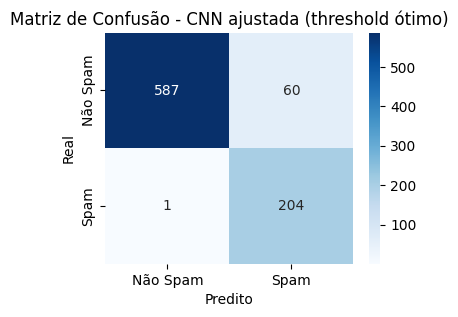

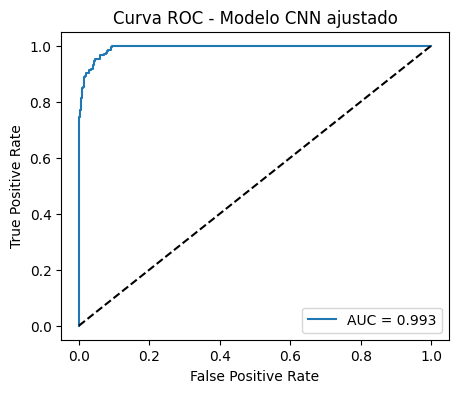

In [11]:
# ============================================================
# Balanceamento de classes + treinamento ajustado
# ============================================================
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time
import torch
import torch.nn as nn
import torch.optim as optim

# ===== 1. Calcular pesos de classe =====
class_weights_np = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# Reduz o peso da classe minoritária (spam) para evitar excesso
class_weights = torch.tensor([1.0, 0.3 * class_weights_np[1]], dtype=torch.float32).to(device)
print("Pesos aplicados às classes [não spam, spam]:", class_weights.cpu().numpy())

# ===== 2. Função de perda ponderada =====
def weighted_bce_loss(output, target, weights):
    loss = -(weights[1]*target*torch.log(output + 1e-8) +
             weights[0]*(1 - target)*torch.log(1 - output + 1e-8))
    return loss.mean()

# ===== 3. Otimizador e hiperparâmetros =====
criterion = nn.BCELoss()  # ainda definido, mas usaremos o ponderado abaixo
optimizer = optim.Adam(model_cnn.parameters(), lr=5e-4)
epochs = 8

# ===== 4. Treinamento =====
print("\nTreinando modelo CNN ajustado...\n")
start_time = time.time()

for epoch in range(epochs):
    model_cnn.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model_cnn(X_batch)
        loss = weighted_bce_loss(outputs, y_batch, class_weights)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Época [{epoch+1}/{epochs}] - Loss médio: {running_loss/len(train_loader):.4f}")

print(f"\nTempo total de treino: {time.time() - start_time:.2f} s")

# ============================================================
# Avaliação detalhada
# ============================================================
model_cnn.eval()
y_true, y_pred_probs = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model_cnn(X_batch)
        y_pred_probs.extend(outputs.cpu().numpy())
        y_true.extend(y_batch.numpy())

y_pred_probs = np.array(y_pred_probs)
y_true = np.array(y_true)

# ===== 5. Encontrar threshold ótimo pela curva ROC =====
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"\nThreshold ótimo encontrado: {optimal_threshold:.3f}")

# Aplicar threshold ótimo
y_pred = (y_pred_probs > optimal_threshold).astype(int)

# ===== 6. Métricas =====
print("\n==== Avaliação no conjunto de teste ====")
print("AUC:", roc_auc_score(y_true, y_pred_probs))
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))

# ===== 7. Matriz de confusão =====
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Não Spam","Spam"], yticklabels=["Não Spam","Spam"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - CNN ajustada (threshold ótimo)")
plt.show()

# ===== 8. Curva ROC =====
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_true, y_pred_probs):.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelo CNN ajustado")
plt.legend(loc="lower right")
plt.show()


## Novo modelo proposto pelo grupo

##### Referências:

Kim, Y. (2014). Convolutional Neural Networks for Sentence Classification. In Proceedings of the 2014 Conference on Empirical Methods in Natural Language Processing (EMNLP), pp. 1746–1751.

Bahdanau, D., Cho, K., & Bengio, Y. (2015). Neural Machine Translation by Jointly Learning to Align and Translate. In Proceedings of the International Conference on Learning Representations (ICLR).

Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). Attention is All You Need. In Advances in Neural Information Processing Systems (NeurIPS).

Snell, J., Swersky, K., & Zemel, R. (2017). Prototypical Networks for Few-Shot Learning. In Advances in Neural Information Processing Systems (NeurIPS).

##### Por que utilizamos o CNN

A base do modelo é uma Convolutional Neural Network (CNN) voltada para processamento de texto, conforme proposto por Kim (2014), que demonstrou a eficiência das convoluções unidimensionais na extração de n-grams semânticos relevantes para tarefas de classificação textual. Essa arquitetura permite capturar padrões locais como combinações de palavras, expressões típicas de spam e estruturas textuais recorrentes em mensagens maliciosas.

#### Proposta 

Entretanto, um modelo CNN convencional tende a tratar todos os tokens de entrada de forma uniforme, não diferenciando aqueles que são semanticamente mais próximos do conteúdo de spam.

Para contornar essa limitação, o presente trabalho incorpora um mecanismo de atenção matemática customizado, inspirado em dois conceitos teóricos fundamentais: (i) o uso de vetores prototípicos de classe, conforme proposto por Snell, Swersky e Zemel (2017), e (ii) o cálculo de atenção baseada em similaridade, conforme introduzido por Bahdanau, Cho e Bengio (2015) e formalizado posteriormente por Vaswani et al. (2017).

O mecanismo proposto consiste em calcular um vetor protótipo de spam, que representa o “centro semântico” dessa classe no espaço de embeddings. Esse vetor é obtido a partir da média das embeddings de todas as mensagens rotuladas como spam no conjunto de treinamento. Em seguida, para cada nova entrada textual, é calculada a similaridade coseno entre as embeddings dos tokens e o vetor protótipo, conforme a Equação (1):

$$A = \frac{1}{N} \sum_{i=1}^{n} \frac{Ei * P}{||Ei|| ||P||}$$

onde 𝐸i representa a embedding do token i, P é o vetor protótipo de spam e N é o número de tokens da sequência. O resultado A é uma pontuação escalar que indica o grau médio de alinhamento semântico do texto com o perfil típico de spam.

Essa pontuação é então concatenada ao vetor de características extraído pela CNN, que resulta da aplicação de camadas convolucionais paralelas com diferentes tamanhos de kernel (por exemplo, 3, 4 e 5). A combinação entre o vetor convolucional e a pontuação de atenção forma a entrada de uma camada totalmente conectada (Linear + ReLU + Dropout), responsável pela integração das informações locais e globais. Por fim, uma camada de ativação sigmoide fornece a probabilidade final de a mensagem pertencer à classe spam.


#### Resumo da estrutura geral

A estrutura geral do modelo pode ser descrita em seis etapas principais:

1. Camada de embedding: transforma os tokens em vetores densos de dimensão fixa.

2. Camadas convolucionais (Conv1D): extraem padrões locais de palavras e expressões.

3. Pooling global: reduz a sequência para um vetor fixo que representa o texto.

4. Cálculo da atenção matemática: computa a similaridade média entre as embeddings dos tokens e o vetor protótipo de spam.

5. Concatenação das representações: une o vetor CNN e a pontuação de atenção em um único vetor.

6. Camadas densas e saída sigmoide: realizam a decisão final de classificação.

In [12]:
# Extrair embeddings do modelo CNN
embedding_layer = model_cnn.embedding  # Embedding já treinada ou inicial
embedding_weights = embedding_layer.weight.data  # [vocab_size, emb_dim]

# Seleciona índices dos spams no treino
spam_indices = np.where(y_train == 1)[0]
X_train_spam = X_train[spam_indices]

# Calcula média das embeddings dos tokens de spam
def compute_spam_prototype(X_spam, embedding_weights):
    vectors = []
    for seq in X_spam:
        token_vecs = embedding_weights[torch.tensor(seq).to(device)]  # pegar embeddings
        seq_mean = token_vecs.mean(dim=0)
        vectors.append(seq_mean)
    return torch.stack(vectors).mean(dim=0)  # protótipo final

spam_prototype = compute_spam_prototype(X_train_spam, embedding_weights)

In [13]:
class CreativeCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, num_filters=128, kernel_sizes=[3,4,5], spam_prototype=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(num_filters * len(kernel_sizes) + 1, 32)  # +1 para a feature de atenção
        self.fc2 = nn.Linear(32,1)
        self.sigmoid = nn.Sigmoid()
        self.spam_prototype = spam_prototype  # vetor spam médio

    def forward(self, x):
        x_emb = self.embedding(x).permute(0,2,1)  # [batch, emb_dim, seq_len]
        conv_outs = [torch.relu(conv(x_emb)) for conv in self.convs]
        pooled = [torch.max(out, dim=2)[0] for out in conv_outs]
        cnn_vec = torch.cat(pooled, dim=1)  # [batch, num_filters*len(kernels)]
        
        # ===== Atenção custom (similaridade média token × spam protótipo) =====
        batch_size, seq_len = x.shape
        token_embs = self.embedding(x)  # [batch, seq_len, emb_dim]
        # Similaridade coseno: <token, protótipo> / (||token||*||protótipo||)
        spam_proto_norm = self.spam_prototype / (self.spam_prototype.norm() + 1e-8)
        token_norms = token_embs / (token_embs.norm(dim=2, keepdim=True)+1e-8)
        similarity = (token_norms @ spam_proto_norm)  # [batch, seq_len]
        attention_feature = similarity.mean(dim=1, keepdim=True)  # scalar por batch

        # Concatena CNN + atenção
        combined = torch.cat([cnn_vec, attention_feature], dim=1)
        out = torch.relu(self.fc1(combined))
        out = self.dropout(out)
        out = self.sigmoid(self.fc2(out))
        return out.squeeze()


In [14]:
model_creative = CreativeCNN(vocab_size=MAX_WORDS, spam_prototype=spam_prototype).to(device)


Pesos aplicados às classes [não spam, spam]: [1.        0.6226553]

Treinando modelo criativo (CNN + Atenção Matemática)...

Época [1/8] - Loss médio: 0.4251
Época [2/8] - Loss médio: 0.3571
Época [3/8] - Loss médio: 0.2931
Época [4/8] - Loss médio: 0.2299
Época [5/8] - Loss médio: 0.1791
Época [6/8] - Loss médio: 0.1359
Época [7/8] - Loss médio: 0.1007
Época [8/8] - Loss médio: 0.0758

Tempo total de treino: 23.59 s

Threshold ótimo encontrado: 0.236

==== Avaliação no conjunto de teste ====
AUC: 0.9950
Accuracy: 0.9777
Precision: 0.9471
Recall: 0.9610
F1: 0.9540


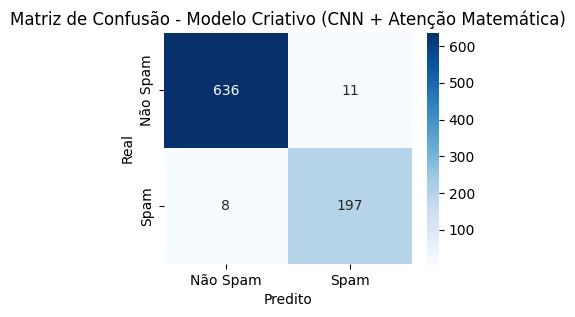

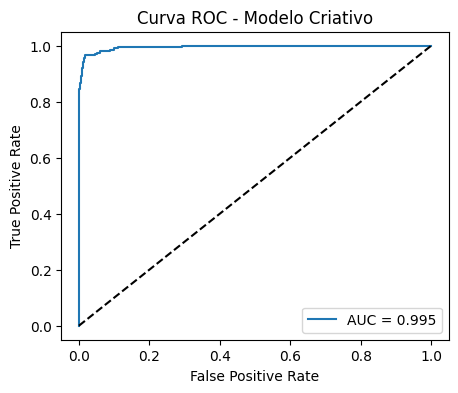

In [15]:
# Treinamento e avaliação do modelo criativo (CNN + Atenção Matemática)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

# ===== 1. Calcular pesos de classe =====
class_weights_np = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor([1.0, 0.3 * class_weights_np[1]], dtype=torch.float32).to(device)
print("Pesos aplicados às classes [não spam, spam]:", class_weights.cpu().numpy())

# ===== 2. Função de perda ponderada =====
def weighted_bce_loss(output, target, weights):
    loss = -(weights[1]*target*torch.log(output + 1e-8) +
             weights[0]*(1 - target)*torch.log(1 - output + 1e-8))
    return loss.mean()

# ===== 3. Otimizador e hiperparâmetros =====
optimizer = optim.Adam(model_creative.parameters(), lr=5e-4)
epochs = 8

# ===== 4. Treinamento =====
print("\nTreinando modelo criativo (CNN + Atenção Matemática)...\n")
start_time = time.time()

for epoch in range(epochs):
    model_creative.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model_creative(X_batch)
        loss = weighted_bce_loss(outputs, y_batch, class_weights)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Época [{epoch+1}/{epochs}] - Loss médio: {running_loss/len(train_loader):.4f}")

print(f"\nTempo total de treino: {time.time() - start_time:.2f} s")

# Avaliação detalhada
model_creative.eval()
y_true, y_pred_probs = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model_creative(X_batch)
        y_pred_probs.extend(outputs.cpu().numpy())
        y_true.extend(y_batch.numpy())

y_pred_probs = np.array(y_pred_probs)
y_true = np.array(y_true)

# ===== 5. Encontrar threshold ótimo pela curva ROC =====
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"\nThreshold ótimo encontrado: {optimal_threshold:.3f}")

# Aplicar threshold ótimo
y_pred = (y_pred_probs > optimal_threshold).astype(int)

# ===== 6. Métricas =====
auc = roc_auc_score(y_true, y_pred_probs)
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\n==== Avaliação no conjunto de teste ====")
print(f"AUC: {auc:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1: {f1:.4f}")

# ===== 7. Matriz de confusão =====
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Não Spam","Spam"], yticklabels=["Não Spam","Spam"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Modelo Criativo (CNN + Atenção Matemática)")
plt.show()

# ===== 8. Curva ROC =====
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelo Criativo")
plt.legend(loc="lower right")
plt.show()


In [16]:

#SUBMISSÃO KAGGLE

model = model_creative.to(device)
# 1. Carregar o conjunto de teste do Kaggle
test_df = pd.read_csv("eval_students_2.csv")

X_test_texts = test_df["text"].astype(str).values
test_ids = test_df["id"].values

# 2. Tokenização (USANDO O MESMO TOKENIZER DO TREINO)
test_sequences = tokenizer.texts_to_sequences(X_test_texts)
X_test_pad = pad_sequences(test_sequences, maxlen=MAX_LEN)

# 3. Converter para tensor PyTorch
X_test_tensor = torch.tensor(X_test_pad, dtype=torch.long).to(device)

# 4. Colocar o modelo em modo avaliação
model.eval()

# 5. Gerar predições
with torch.no_grad():
    y_probs = model(X_test_tensor).squeeze()
    y_probs = y_probs.cpu().numpy()

# 6. Converter probabilidades em classes (threshold = 0.5)
y_pred = (y_probs >= 0.5).astype(int)

# 7. Criar DataFrame de submissão
submission_df = pd.DataFrame({
    "id": test_ids,
    "spam": y_pred
})

# 8. Salvar arquivo CSV
submission_df.to_csv("submission.csv", index=False)

print("Arquivo submission.csv gerado com sucesso!")
submission_df.head()


Arquivo submission.csv gerado com sucesso!


,id,spam
0,5074,0
1,2941,0
2,2032,1
3,3443,0
4,3063,0


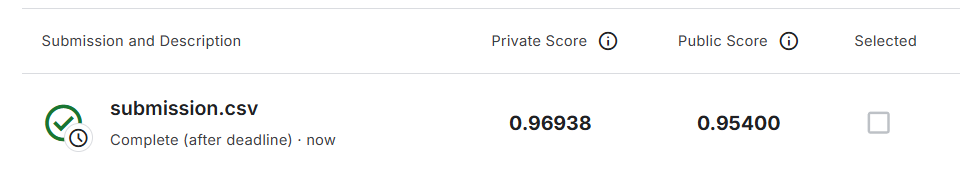